# Flickr30k Dataset Viewer

**模态**: Image + Text (image-caption pairs)

- 31,014 张图片，每张配 5 条英文描述
- Split: train (29,000) / val (1,014) / test (1,000)
- 用于 image-text 对比学习、检索、captioning

In [1]:
import os
import ast
import zipfile
import io
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE = os.path.abspath(os.path.join(os.getcwd(), '..', 'dataset', 'flickr30k'))
ANNOTATIONS = os.path.join(BASE, 'flickr_annotations_30k.csv')
IMAGES_ZIP = os.path.join(BASE, 'flickr30k-images.zip')

print(f'Annotations: {os.path.exists(ANNOTATIONS)} ({os.path.getsize(ANNOTATIONS)/1e6:.1f} MB)')
print(f'Images ZIP:  {os.path.exists(IMAGES_ZIP)} ({os.path.getsize(IMAGES_ZIP)/1e9:.2f} GB)')

Annotations: True (12.9 MB)
Images ZIP:  True (4.39 GB)


## 1. Load Annotations

In [2]:
df = pd.read_csv(ANNOTATIONS)
df['captions'] = df['raw'].apply(ast.literal_eval)
df['num_captions'] = df['captions'].str.len()
print(f'Total rows: {len(df)}')
print(f'Unique images: {df["filename"].nunique()}')
print(f'\nSplit distribution:')
print(df['split'].value_counts().to_string())
print(f'\nCaptions per image: always {df["num_captions"].unique()}')
df.head(3)

Total rows: 31014
Unique images: 31014

Split distribution:
split
train    29000
val       1014
test      1000

Captions per image: always [5]


,raw,sentids,split,filename,img_id,captions,num_captions
0,"[""Two young guys with shaggy hair look at thei...","[0, 1, 2, 3, 4]",train,1000092795.jpg,0,[Two young guys with shaggy hair look at their...,5
1,"[""Several men in hard hats are operating a gia...","[5, 6, 7, 8, 9]",train,10002456.jpg,1,[Several men in hard hats are operating a gian...,5
2,"[""A child in a pink dress is climbing up a set...","[10, 11, 12, 13, 14]",train,1000268201.jpg,2,[A child in a pink dress is climbing up a set ...,5


## 2. Caption Statistics

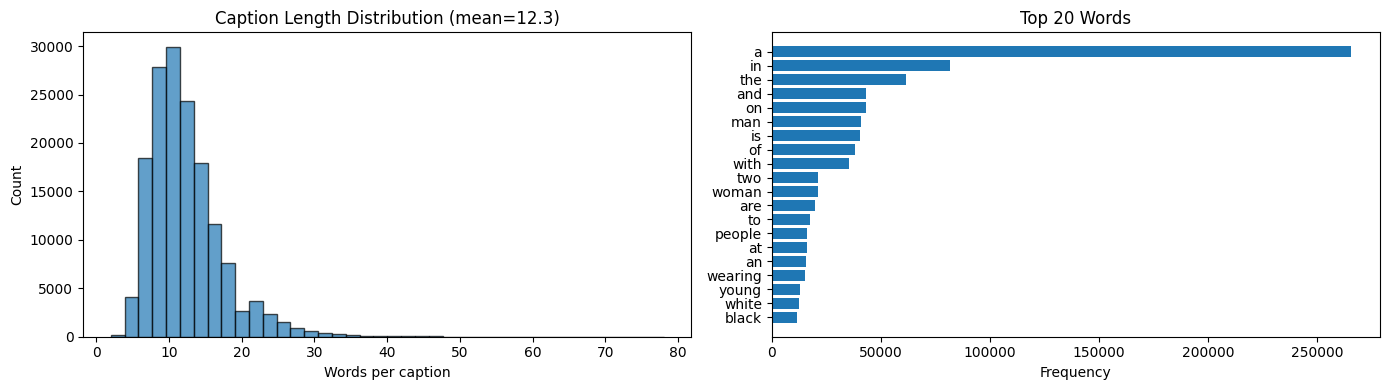

Total captions: 155070
Unique words: 31101
Min/Max words: 2 / 78


In [3]:
all_captions = [c for caps in df['captions'] for c in caps]
lengths = [len(c.split()) for c in all_captions]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(lengths, bins=40, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Words per caption')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Caption Length Distribution (mean={sum(lengths)/len(lengths):.1f})')

word_counts = {}
for c in all_captions:
    for w in c.lower().split():
        word_counts[w] = word_counts.get(w, 0) + 1
top20 = sorted(word_counts.items(), key=lambda x: -x[1])[:20]
axes[1].barh([w for w, _ in reversed(top20)], [c for _, c in reversed(top20)])
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 20 Words')
plt.tight_layout()
plt.show()

print(f'Total captions: {len(all_captions)}')
print(f'Unique words: {len(word_counts)}')
print(f'Min/Max words: {min(lengths)} / {max(lengths)}')

## 3. Preview Images + Captions (from ZIP)

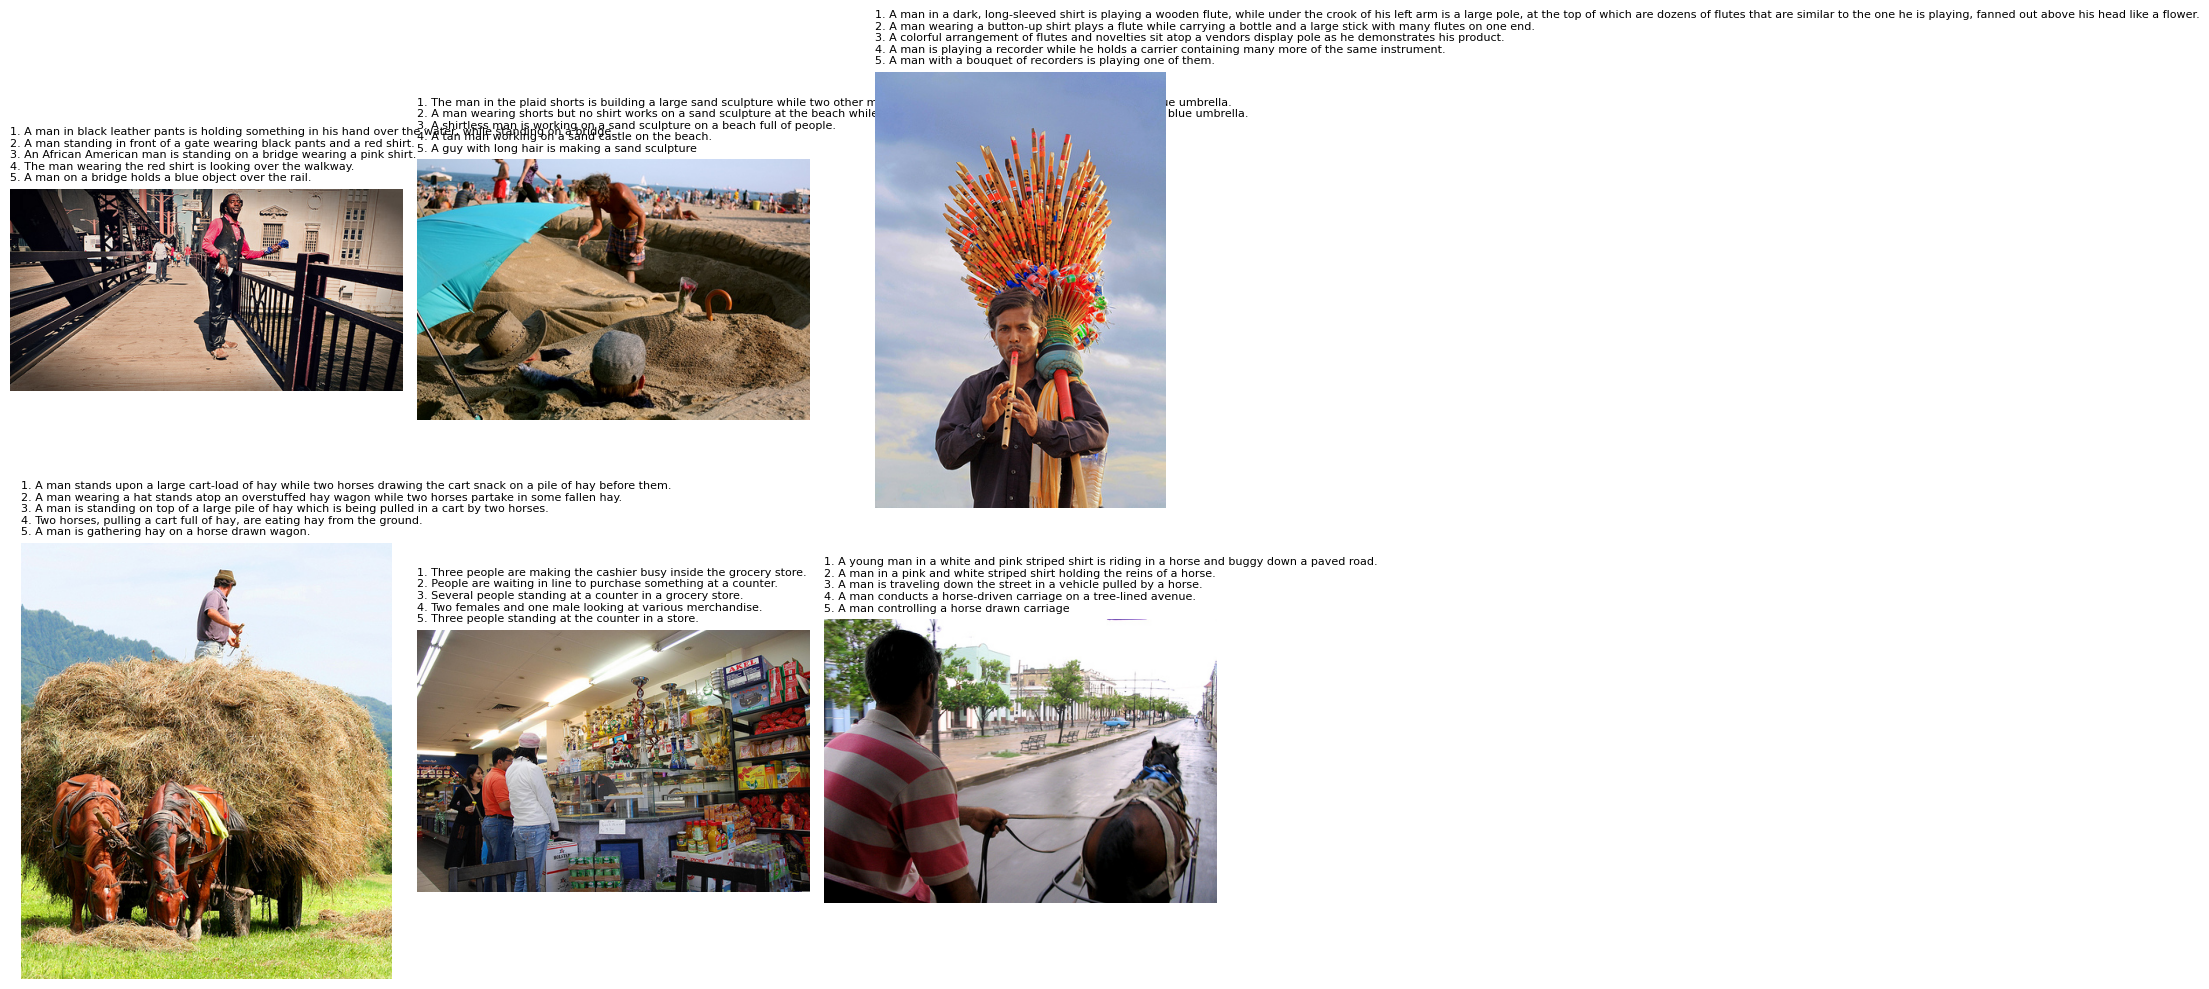

In [4]:
N_SHOW = 6
sample_df = df.sample(N_SHOW, random_state=42)

zip_opened = zipfile.ZipFile(IMAGES_ZIP, 'r')
name_list = set(zip_opened.namelist())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    fname = row['filename']
    zip_path = f'flickr30k-images/{fname}'
    if zip_path in name_list:
        data = zip_opened.read(zip_path)
        img = Image.open(io.BytesIO(data))
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found in zip', ha='center', va='center')
    caps = row['captions']
    title = '\n'.join([f'{i+1}. {c}' for i, c in enumerate(caps)])
    ax.set_title(title, fontsize=8, loc='left')
    ax.axis('off')
plt.tight_layout()
plt.show()
zip_opened.close()

## 4. Image Size Distribution (sampled)

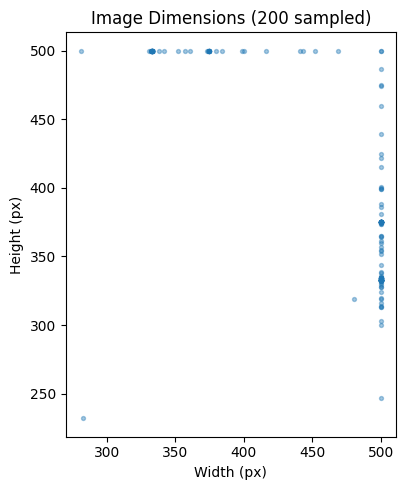

Width:  281–500 (median 500)
Height: 232–500 (median 375)


In [5]:
SAMPLE_N = 200
sample_imgs = df.sample(SAMPLE_N, random_state=123)
zip_ref = zipfile.ZipFile(IMAGES_ZIP, 'r')

widths, heights = [], []
for _, row in sample_imgs.iterrows():
    zip_path = f'flickr30k-images/{row["filename"]}'
    try:
        data = zip_ref.read(zip_path)
        img = Image.open(io.BytesIO(data))
        w, h = img.size
        widths.append(w)
        heights.append(h)
    except KeyError:
        pass
zip_ref.close()

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(widths, heights, alpha=0.4, s=8)
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
ax.set_title(f'Image Dimensions ({len(widths)} sampled)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
print(f'Width:  {min(widths)}–{max(widths)} (median {sorted(widths)[len(widths)//2]})')
print(f'Height: {min(heights)}–{max(heights)} (median {sorted(heights)[len(heights)//2]})')

## 5. Sample Captions by Split

In [6]:
for split in ['train', 'val', 'test']:
    subset = df[df['split'] == split]
    row = subset.iloc[0]
    print(f'--- {split} (n={len(subset)}) ---')
    print(f'  File: {row["filename"]}')
    for i, c in enumerate(row['captions']):
        print(f'  [{i}] {c}')
    print()

--- train (n=29000) ---
  File: 1000092795.jpg
  [0] Two young guys with shaggy hair look at their hands while hanging out in the yard.
  [1] Two young, White males are outside near many bushes.
  [2] Two men in green shirts are standing in a yard.
  [3] A man in a blue shirt standing in a garden.
  [4] Two friends enjoy time spent together.

--- val (n=1014) ---
  File: 1018148011.jpg
  [0] A group of people stand in the back of a truck filled with cotton.
  [1] Men are standing on and about a truck carrying a white substance.
  [2] A group of people are standing on a pile of wool in a truck.
  [3] A group of men are loading cotton onto a truck
  [4] Workers load sheared wool onto a truck.

--- test (n=1000) ---
  File: 1007129816.jpg
  [0] The man with pierced ears is wearing glasses and an orange hat.
  [1] A man with glasses is wearing a beer can crocheted hat.
  [2] A man with gauges and glasses is wearing a Blitz hat.
  [3] A man in an orange hat starring at something.
  [4] A ma